In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
system_labels = [r"rhTRIM5$\alpha$",r"huTRIM5$\alpha$",r"huTRIM5$\alpha^{R332P}$"]

systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(291,495)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
def GetDistMapTimeseries(tu,importantResids,additionalSel):

    pocketSelectionString = additionalSel+" and ("
    for i in range(len(importantResids)):
        pocketSelectionString+= "resid " + str(importantResids[i])+" or "
    pocketSelectionString=pocketSelectionString[:-4]+")"



    dists_timeseries=[]
    for t in range(len(tu.trajectory)):
        tu.trajectory[t]
        pocketCAs = tu.select_atoms(pocketSelectionString, updating = True)
        dists = MDAnalysis.analysis.distances.distance_array(pocketCAs.atoms.positions,pocketCAs.atoms.positions)
        dists_timeseries.append(dists)
    return dists_timeseries

importantResids = arange(320,350)


needDists = False
if needDists == True:

    all_dists_timeseries=[]
    for i in range(len(systems)):
        sub = []
        for j in range(len(systems[i])):
            sub.append(GetDistMapTimeseries(systems[i][j],importantResids,""))

        all_dists_timeseries.append(sub)



        
    #save("v1_pairwiseDistances_2d.npy",all_dists_timeseries)

else:
    all_dists_timeseries=load("v1_pairwiseDistances_2d.npy")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 1000)
newcolors = viridis(np.linspace(0, 1, 1000))
#This is what you pick
rs = concatenate([linspace(51,256,500),linspace(256,136,500)])/256
gs = concatenate([linspace(34,256,500),linspace(256,34,500)])/256
bs = concatenate([linspace(136,256,500),linspace(256,85,500)])/256
newColours = []
for i in range(len(rs)):
    newColours.append([rs[i],gs[i],bs[i],1])
newcolors = newColours
newcmp = ListedColormap(newcolors)

mean_all_eqdists=[]

for i in range(len(all_dists_timeseries)):
    sub = []
    for j in range(len(all_dists_timeseries[i])):
        mean_eq = mean(all_dists_timeseries[i][j][EQPOINT:],axis = 0)
        
        sub.append(mean_eq)
        
    mean_all_eqdists.append(sub)
    
    
system_importantcadists_avg=[]
system_importantcadists_sem=[]
for i in range(len(mean_all_eqdists)):
    system_importantcadists_avg.append(mean(mean_all_eqdists[i],axis = 0))
    system_importantcadists_sem.append(scipy.stats.sem(mean_all_eqdists[i],axis = 0))


In [5]:
systems

[[<Universe with 3190 atoms>,
  <Universe with 3190 atoms>,
  <Universe with 3190 atoms>,
  <Universe with 3190 atoms>,
  <Universe with 3190 atoms>,
  <Universe with 3190 atoms>,
  <Universe with 3190 atoms>,
  <Universe with 3190 atoms>,
  <Universe with 3190 atoms>],
 [<Universe with 3157 atoms>,
  <Universe with 3157 atoms>,
  <Universe with 3157 atoms>,
  <Universe with 3157 atoms>,
  <Universe with 3157 atoms>,
  <Universe with 3157 atoms>,
  <Universe with 3157 atoms>,
  <Universe with 3157 atoms>,
  <Universe with 3157 atoms>],
 [<Universe with 3147 atoms>,
  <Universe with 3147 atoms>,
  <Universe with 3147 atoms>,
  <Universe with 3147 atoms>,
  <Universe with 3147 atoms>,
  <Universe with 3147 atoms>,
  <Universe with 3147 atoms>,
  <Universe with 3147 atoms>,
  <Universe with 3147 atoms>]]

(3.5, 25.5)

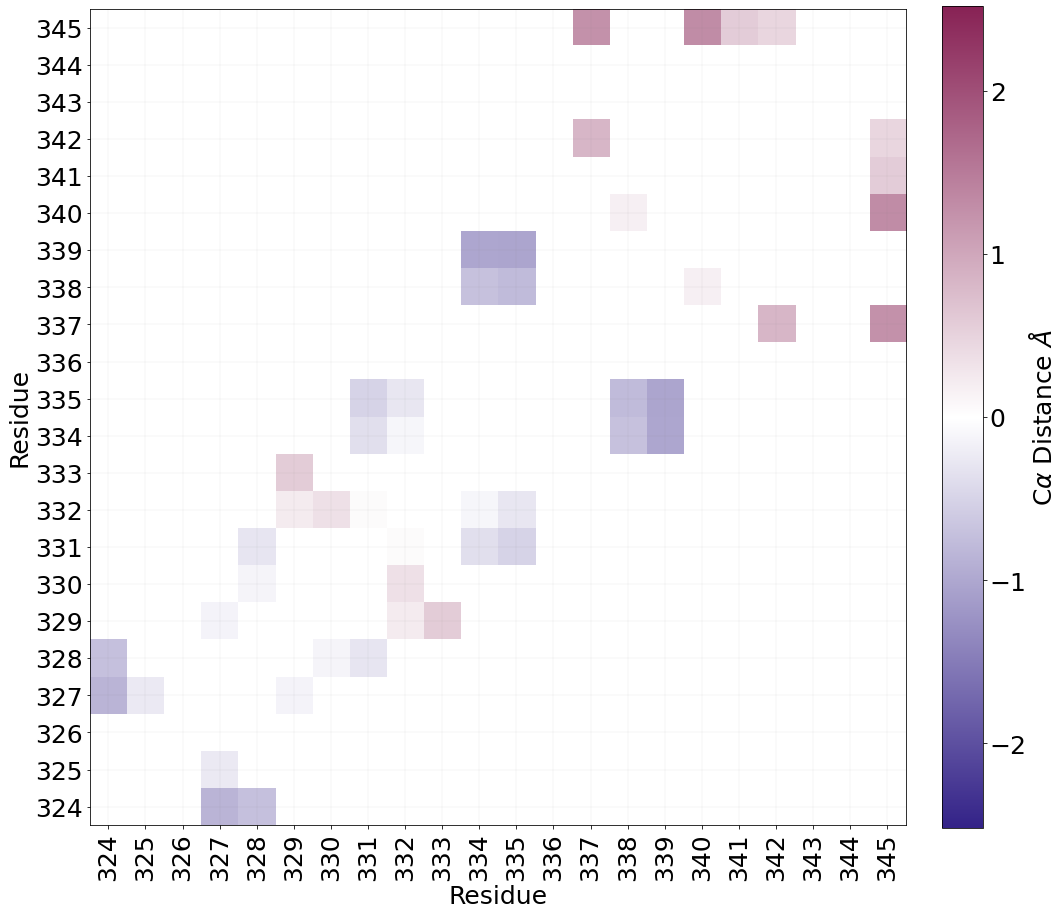

In [6]:

diffmap = system_importantcadists_avg[2] - system_importantcadists_avg[1]
semDiffBars = sqrt(system_importantcadists_sem[2]**2 + system_importantcadists_sem[1]**2)


significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):

        
        if abs(semDiffBars[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0
            #semDiffBars[i] = 0
       
    
        
drange = max(abs(significant_diffbars).flatten())

figure(figsize = (16,16))
imshow(significant_diffbars,origin = "lower",cmap=newcmp,vmin=-drange,vmax=drange)#,extent = (resids_proper[0]-0.5,resids_proper[-1]+0.5,resids_proper[0]-0.5,resids_proper[-1]+0.5))

#5.55.55.5
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label(r"C$\alpha$ Distance $\AA$",fontsize = 25)
xlabel("Residue",fontsize = 25)
ylabel("Residue",fontsize = 25)
#title(r"Important Residue C$\alpha$: Distances " +system_names[2] + " - " + system_names[1]+"\n significant only",fontsize = 25)
dsfasfvdas=xticks(arange(len(importantResids)),importantResids,fontsize = 25,rotation = 90)
asdvfasdvfav=yticks(arange(len(importantResids)),importantResids,fontsize = 25)
  
        
for i in range(len(importantResids)):
    axvline(i,color = "grey",alpha = 0.05)
    axhline(i,color = "grey",alpha = 0.05)         
    
xlim(323.5-320,345.5-320)
ylim(323.5-320,345.5-320)

(3.0, 26.0)

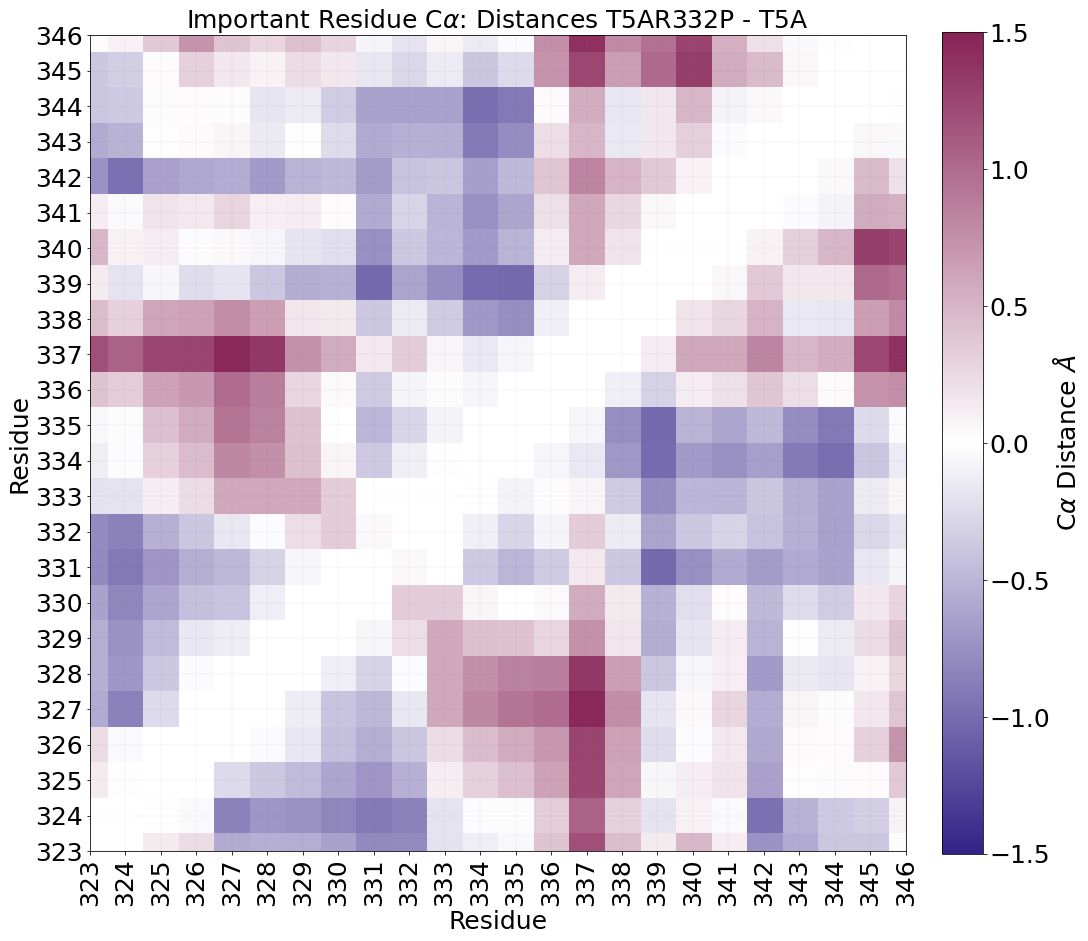

In [7]:

diffmap = system_importantcadists_avg[2] - system_importantcadists_avg[1]
semDiffBars = sqrt(system_importantcadists_sem[2]**2 + system_importantcadists_sem[1]**2)


significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):

        
        if abs(semDiffBars[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0
            #semDiffBars[i] = 0
       
    
        
drange = max(abs(diffmap).flatten())

figure(figsize = (16,16))
imshow(diffmap,origin = "lower",cmap=newcmp,vmin=-1.5,vmax=1.5)#,extent = (resids_proper[0]-0.5,resids_proper[-1]+0.5,resids_proper[0]-0.5,resids_proper[-1]+0.5))

#5.55.55.5
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label(r"C$\alpha$ Distance $\AA$",fontsize = 25)
xlabel("Residue",fontsize = 25)
ylabel("Residue",fontsize = 25)
title(r"Important Residue C$\alpha$: Distances " +system_names[2] + " - " + system_names[1],fontsize = 25)
dsfasfvdas=xticks(arange(len(importantResids)),importantResids,fontsize = 25,rotation = 90)
asdvfasdvfav=yticks(arange(len(importantResids)),importantResids,fontsize = 25)
  
        
for i in range(len(importantResids)):
    axvline(i,color = "grey",alpha = 0.05)
    axhline(i,color = "grey",alpha = 0.05)        
    
xlim(323-320,346-320)
ylim(323-320,346-320)

In [8]:
all_dists_timeseries

array([[[[[ 0.        ,  3.93228976,  7.2308625 , ...,  9.7137107 ,
            7.76766281, 10.26735121],
          [ 3.93228976,  0.        ,  3.86104808, ..., 10.30692663,
            9.65055227, 12.97048365],
          [ 7.2308625 ,  3.86104808,  0.        , ...,  9.93594491,
           10.30895952, 14.09302255],
          ...,
          [ 9.7137107 , 10.30692663,  9.93594491, ...,  0.        ,
            3.84350851,  6.82231643],
          [ 7.76766281,  9.65055227, 10.30895952, ...,  3.84350851,
            0.        ,  3.91495468],
          [10.26735121, 12.97048365, 14.09302255, ...,  6.82231643,
            3.91495468,  0.        ]],

         [[ 0.        ,  3.77711979,  6.93421527, ..., 10.28650791,
            9.09147509, 11.0023681 ],
          [ 3.77711979,  0.        ,  3.76824894, ..., 10.85224772,
           10.79547084, 13.53516982],
          [ 6.93421527,  3.76824894,  0.        , ...,  9.95707545,
           10.83972534, 14.23334501],
          ...,
          [10.

(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

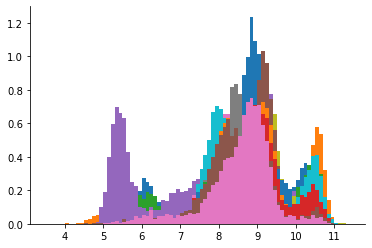

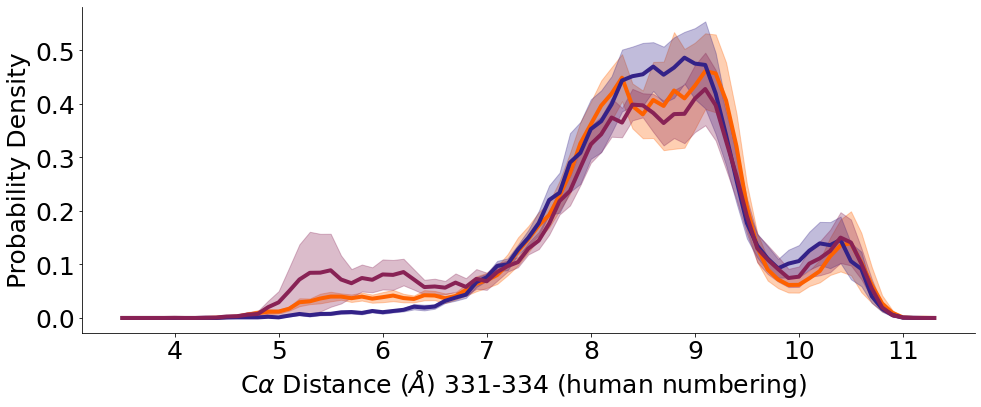

In [16]:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

all_cadists_331_334=[]
binrange=arange(3.5,11.5,.1)
for i in range(len(all_dists_timeseries)):
    sub=[]
    for j in range(len(all_dists_timeseries[i])):
        
        
        a=hist(array(all_dists_timeseries[i][j]).T[12][15],density = True,bins = binrange)
        sub.append(a[0])
    all_cadists_331_334.append(sub)
    
avg_hists_all_cadists_331_334=[]
sem_hists_all_cadists_331_334=[]

for i in range(len(all_cadists_331_334)):
    avg_hists_all_cadists_331_334.append(mean(all_cadists_331_334[i],axis = 0))
    sem_hists_all_cadists_331_334.append(scipy.stats.sem(all_cadists_331_334[i],axis = 0))
    
    
figure(figsize = (16,6))
plot(binrange[:-1],avg_hists_all_cadists_331_334[0],color = colourScheme[0],linewidth = 4)
plot(binrange[:-1],avg_hists_all_cadists_331_334[1],color = colourScheme[1],linewidth = 4)
plot(binrange[:-1],avg_hists_all_cadists_331_334[2],color = colourScheme[2],linewidth = 4)


fill_between(binrange[:-1], avg_hists_all_cadists_331_334[0] - sem_hists_all_cadists_331_334[0],avg_hists_all_cadists_331_334[0] + sem_hists_all_cadists_331_334[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], avg_hists_all_cadists_331_334[1] - sem_hists_all_cadists_331_334[1],avg_hists_all_cadists_331_334[1] + sem_hists_all_cadists_331_334[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], avg_hists_all_cadists_331_334[2] - sem_hists_all_cadists_331_334[2],avg_hists_all_cadists_331_334[2] + sem_hists_all_cadists_331_334[2],color = colourScheme[2],alpha = 0.3)


xlabel(r"C$\alpha$ Distance ($\AA$) 331-334 (human numbering)  ",fontsize = 25)
ylabel("Probability Density",fontsize = 25)
#title("Convex Hull Volume of Important Residue CA",fontsize = 30)
xticks(fontsize = 25)
yticks(fontsize = 25)

#legend(fontsize = 25,loc = "lower right")

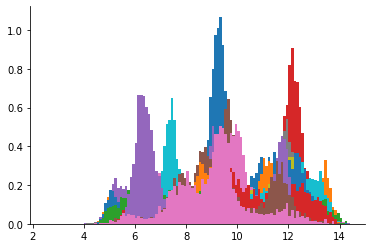

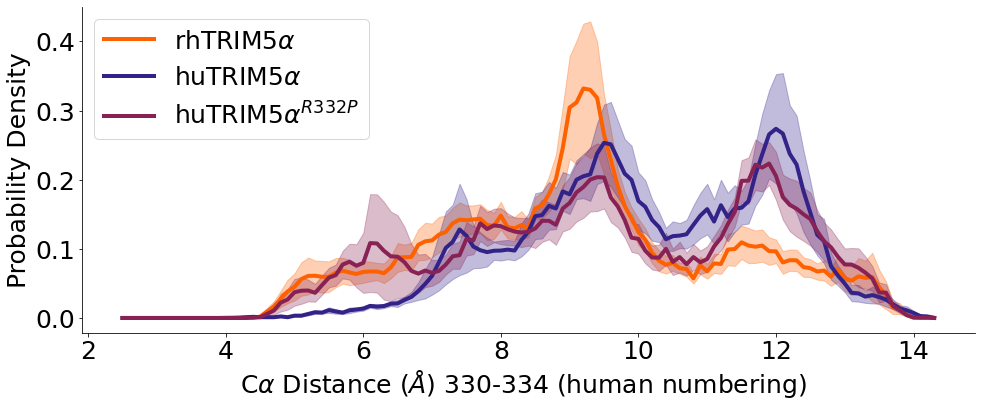

In [9]:
all_cadists_330_334=[]
binrange=arange(2.5,14.5,.1)
for i in range(len(all_dists_timeseries)):
    sub=[]
    for j in range(len(all_dists_timeseries[i])):
        
        
        a=hist(array(all_dists_timeseries[i][j]).T[11][15],density = True,bins = binrange)
        sub.append(a[0])
    all_cadists_330_334.append(sub)
    
avg_hists_all_cadists_330_334=[]
sem_hists_all_cadists_330_334=[]

for i in range(len(all_cadists_330_334)):
    avg_hists_all_cadists_330_334.append(mean(all_cadists_330_334[i],axis = 0))
    sem_hists_all_cadists_330_334.append(scipy.stats.sem(all_cadists_330_334[i],axis = 0))
    
    
figure(figsize = (16,6))
plot(binrange[:-1],avg_hists_all_cadists_330_334[0],color = colourScheme[0],linewidth = 4,label = system_labels[0])
plot(binrange[:-1],avg_hists_all_cadists_330_334[1],color = colourScheme[1],linewidth = 4,label = system_labels[1])
plot(binrange[:-1],avg_hists_all_cadists_330_334[2],color = colourScheme[2],linewidth = 4,label = system_labels[2])


fill_between(binrange[:-1], avg_hists_all_cadists_330_334[0] - sem_hists_all_cadists_330_334[0],avg_hists_all_cadists_330_334[0] + sem_hists_all_cadists_330_334[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], avg_hists_all_cadists_330_334[1] - sem_hists_all_cadists_330_334[1],avg_hists_all_cadists_330_334[1] + sem_hists_all_cadists_330_334[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], avg_hists_all_cadists_330_334[2] - sem_hists_all_cadists_330_334[2],avg_hists_all_cadists_330_334[2] + sem_hists_all_cadists_330_334[2],color = colourScheme[2],alpha = 0.3)


xlabel(r"C$\alpha$ Distance ($\AA$) 330-334 (human numbering)  ",fontsize = 25)
ylabel("Probability Density",fontsize = 25)
#title("Convex Hull Volume of Important Residue CA",fontsize = 30)
xticks(fontsize = 25)
yticks(fontsize = 25)

legend(fontsize = 25,loc = "upper left")

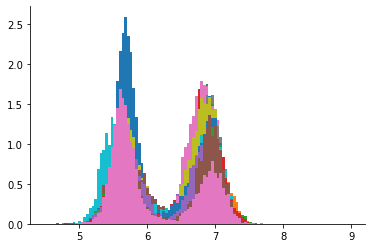

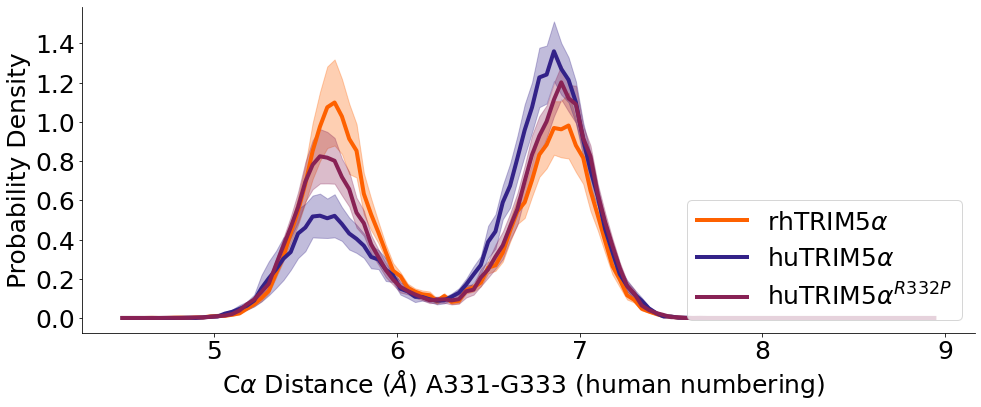

In [10]:


all_cadists_331_333=[]
binrange=arange(4.5,9,.04)
for i in range(len(all_dists_timeseries)):
    sub=[]
    for j in range(len(all_dists_timeseries[i])):
        
        
        a=hist(array(all_dists_timeseries[i][j]).T[12][14],density = True,bins = binrange)
        sub.append(a[0])
    all_cadists_331_333.append(sub)
    
avg_hists_all_cadists_331_333=[]
sem_hists_all_cadists_331_333=[]

for i in range(len(all_cadists_331_333)):
    avg_hists_all_cadists_331_333.append(mean(all_cadists_331_333[i],axis = 0))
    sem_hists_all_cadists_331_333.append(scipy.stats.sem(all_cadists_331_333[i],axis = 0))
    
    
figure(figsize = (16,6))
plot(binrange[:-1],avg_hists_all_cadists_331_333[0],color = colourScheme[0],linewidth = 4,label = system_labels[0])
plot(binrange[:-1],avg_hists_all_cadists_331_333[1],color = colourScheme[1],linewidth = 4,label = system_labels[1])
plot(binrange[:-1],avg_hists_all_cadists_331_333[2],color = colourScheme[2],linewidth = 4,label = system_labels[2])


fill_between(binrange[:-1], avg_hists_all_cadists_331_333[0] - sem_hists_all_cadists_331_333[0],avg_hists_all_cadists_331_333[0] + sem_hists_all_cadists_331_333[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], avg_hists_all_cadists_331_333[1] - sem_hists_all_cadists_331_333[1],avg_hists_all_cadists_331_333[1] + sem_hists_all_cadists_331_333[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], avg_hists_all_cadists_331_333[2] - sem_hists_all_cadists_331_333[2],avg_hists_all_cadists_331_333[2] + sem_hists_all_cadists_331_333[2],color = colourScheme[2],alpha = 0.3)


xlabel(r"C$\alpha$ Distance ($\AA$) A331-G333 (human numbering)  ",fontsize = 25)
ylabel("Probability Density",fontsize = 25)
#title("Convex Hull Volume of Important Residue CA",fontsize = 30)
xticks(fontsize = 25)
yticks(fontsize = 25)

legend(fontsize = 25,loc = "lower right")